<a href="https://colab.research.google.com/github/jmeliss/Banco-de-Dados/blob/main/Welcome_to_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler

plt.rcParams['figure.figsize']=[15,10]

In [12]:
url = 'https://raw.githubusercontent.com/higoramario/univesp-com410-aprendizado-de-maquinas/main/social-network-ads.csv'
compras = pd.read_csv(url, sep=',')
compras.head(10)

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0
5,27,58000,0
6,27,84000,0
7,32,150000,1
8,25,33000,0
9,35,65000,0


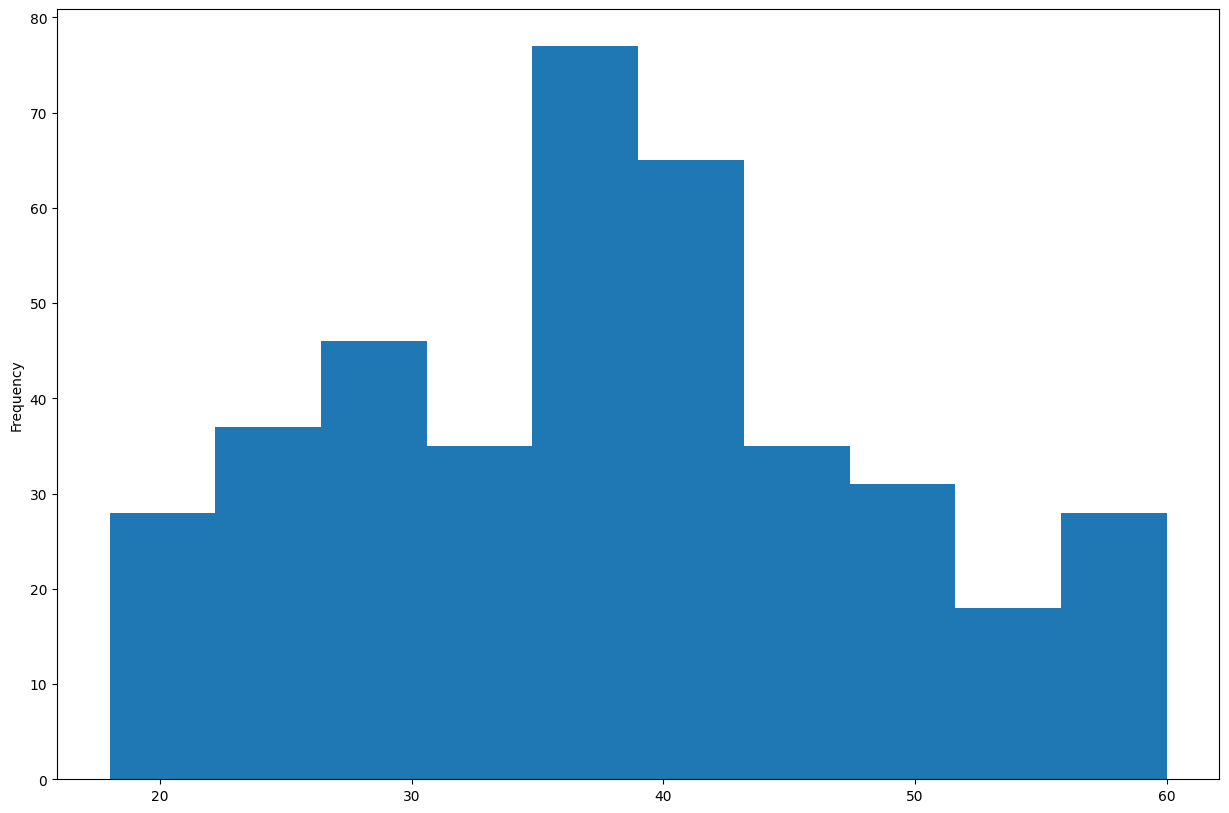

In [13]:
compras['Age'].plot.hist()
plt.show()

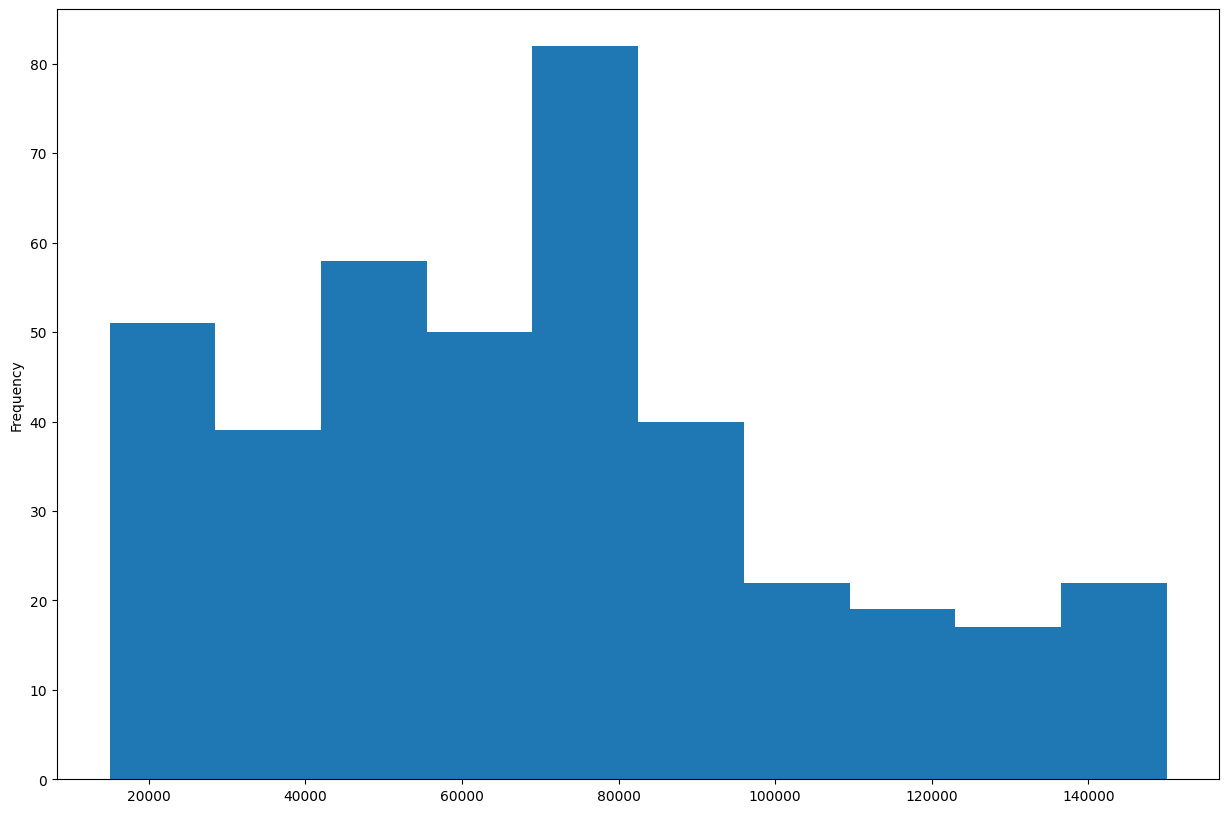

In [14]:
plt.figure(figsize=(15,10))
compras['EstimatedSalary'].plot.hist()
plt.show()

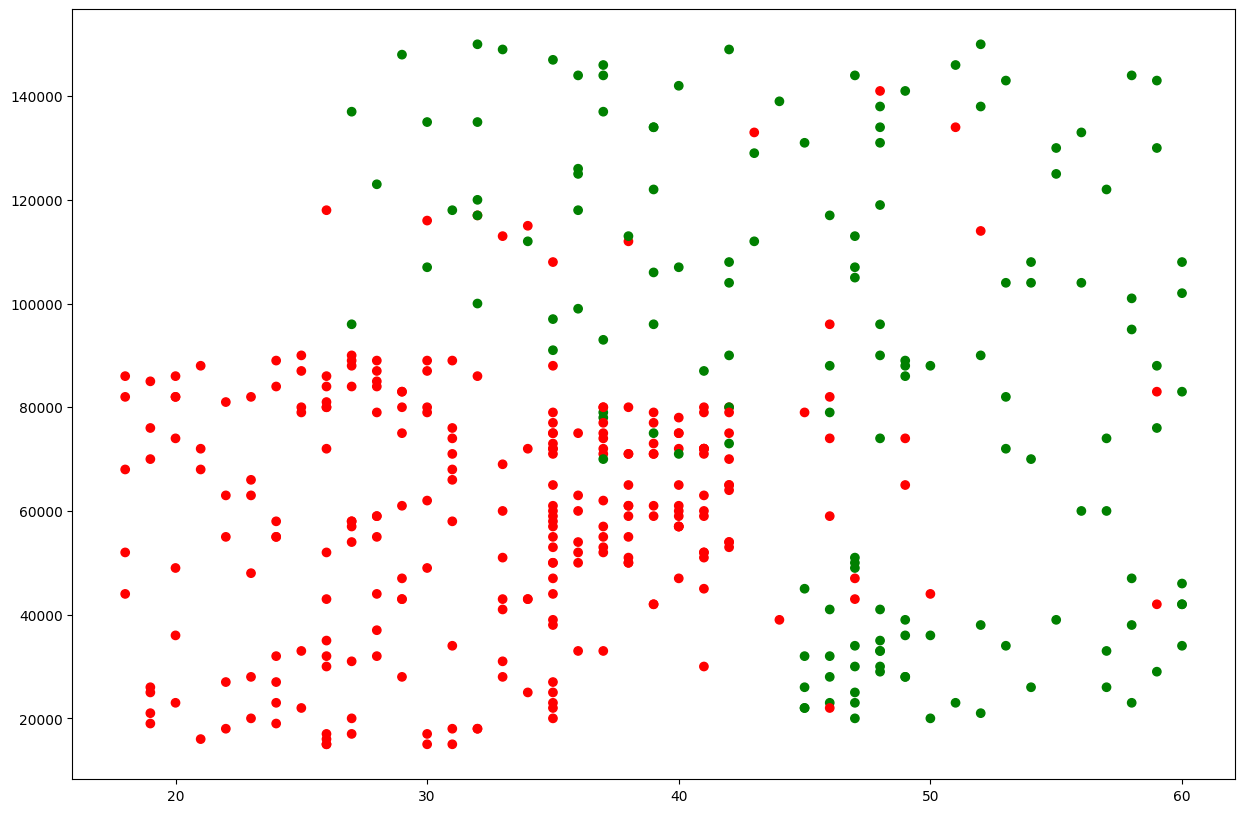

In [15]:
fig, ax = plt.subplots()
colors = {0:'red', 1:'green'}
ax.scatter(compras['Age'], compras['EstimatedSalary'], c=compras['Purchased'].map(colors))
plt.show()

In [24]:
atributos = compras[['Age', 'EstimatedSalary']]
classes = compras['Purchased']

In [25]:
compras_treino, compras_teste, classes_treino, classes_teste = train_test_split(atributos, classes, test_size=10)

In [26]:
scaler = StandardScaler()
compras_treinos = scaler.fit_transform(compras_treino)
compras_test = scaler.transform(compras_teste)

funçao que recebe os atributos e classes do conjunto de testes, o classificador SVM e plota os resultados

In [32]:
def visualizarSVM(atributos_t,classes_t,classificador):
  atributos, classes = atributos_t, classes_t

  ano, salario = np.meshgrid(np.arange(start = atributos[:, 0].min() - 1, stop = atributos[:, 0].max() + 1, step = 0.01),
                             np.arange(start = atributos[:, 1].min() - 1, stop = atributos[:, 1].max() + 1, step = 0.01))

  plt.contourf(ano, salario, classificador.predict(np.array([ano.ravel(), salario.ravel()]).T).reshape(ano.shape),
               alpha = 0.75, cmap = ListedColormap(('red', 'green')))
  plt.xlim(ano.min(), ano.max())
  plt.ylim(salario.min(), salario.max())

  for i, j in enumerate(np.unique(classes)):
    plt.scatter(atributos[classes == j, 0], atributos[classes == j, 1],
                color = ListedColormap(('red', 'green'))(i), label = j)
  plt.title('Classificação SVM')
  plt.xlabel('Ano')
  plt.ylabel('Salário Estimado')
  plt.legend()
  plt.show()

In [28]:
SVM_polinomial = SVC(kernel='poly', degree=3, gamma = 'scale', C= 1.0, coef0=2)
SVM_polinomial.fit(compras_treino, classes_treino)

SVC(coef0=2, kernel='poly')

In [29]:
predicao = SVM_polinomial.predict(compras_teste)
acuracia = accuracy_score(classes_teste, predicao)
print('Acuracia de classificação: {}',format(round(acuracia,3)*100)+'%')

Acuracia de classificação: {} 100.0%


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


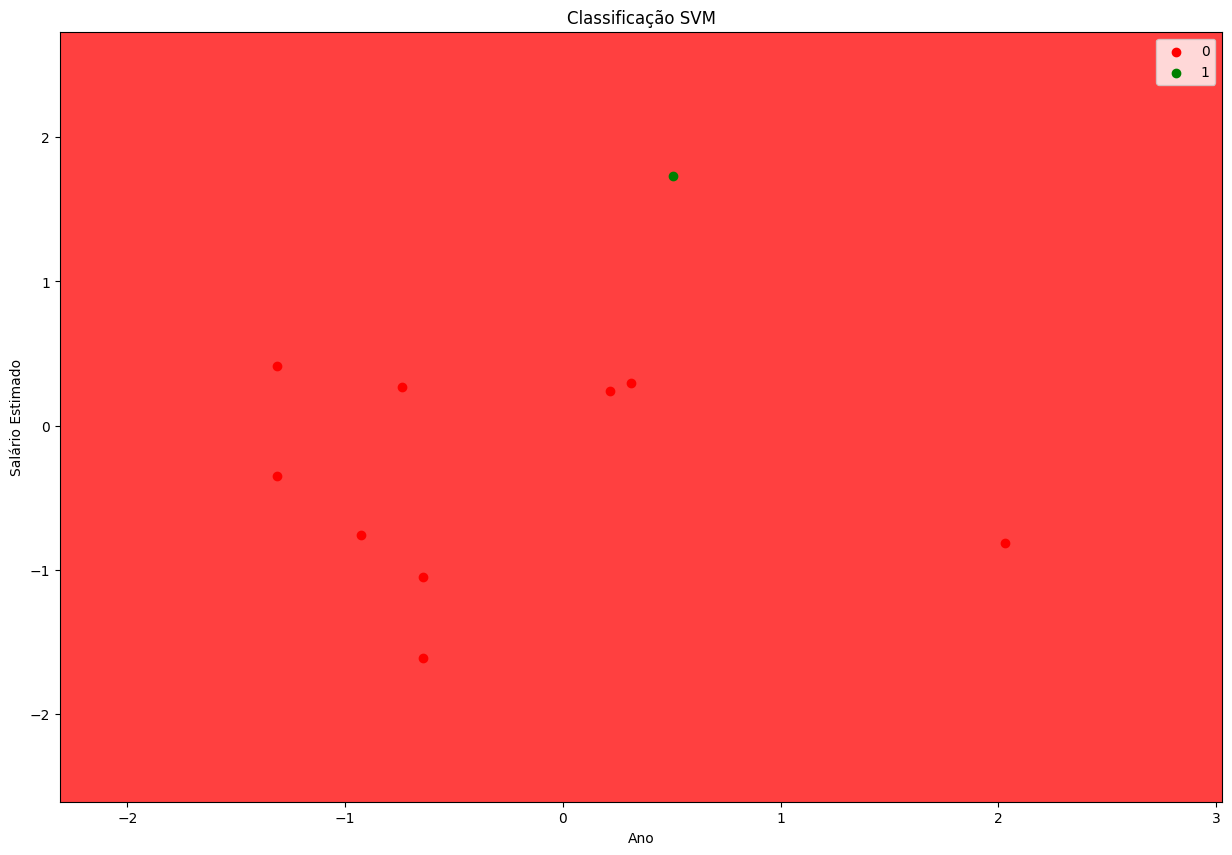

In [30]:
visualizarSVM(compras_test, classes_teste, SVM_polinomial)

In [33]:
SVM_sigmoidal = SVC(kernel = 'sigmoid', gamma = 'scale', C = 0.2, coef0=2)

In [35]:
SVM_sigmoidal.fit(compras_treinos, classes_treino)
predicao_sigmoidal = SVM_sigmoidal.predict(compras_test)

In [36]:
predicao_sigmoidal = SVM_sigmoidal.predict(compras_test)
acuracia_sigmoidal = accuracy_score(classes_teste, predicao_sigmoidal)
print('Acuracia de classificação: {}',format(round(acuracia_sigmoidal,3)*100)+'%')

Acuracia de classificação: {} 80.0%


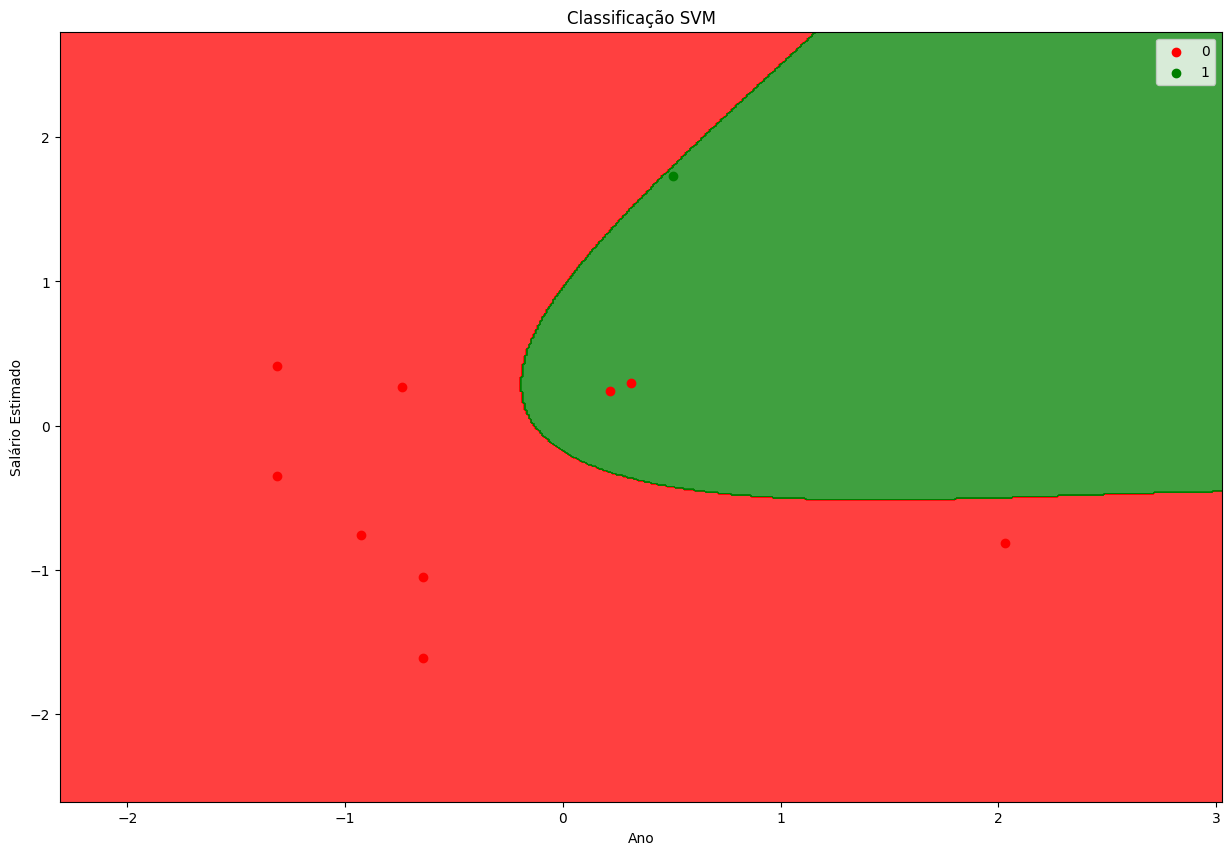

In [37]:
visualizarSVM(compras_test, classes_teste, SVM_sigmoidal)